Some weights of XLMRobertaForSequenceClassification were not initialized from the model checkpoint at xlm-roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

[OPTIMIZER] epoch_start=0 global_step=0 wrapped=AcceleratedOptimizer base=AdamW lr=0.0 id=127555849698864 hyperparams={'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 0.0, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[0.0]
[PARAMS]   params_total=278,045,955 params_trainable=278,045,955


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,Precision Macro,Recall Macro,Mse,Sse
1,1.106000,0.919899,0.700000,0.687787,0.785810,0.700000,0.181879,54.563550
2,0.516800,0.340140,0.870000,0.869342,0.875783,0.870000,0.060881,18.264237
3,0.318500,0.197522,0.936667,0.936583,0.936998,0.936667,0.032310,9.693034
4,0.160400,0.189336,0.946667,0.946551,0.947025,0.946667,0.030335,9.100400
5,0.149800,0.187189,0.943333,0.943357,0.944207,0.943333,0.031327,9.398099
6,0.124100,0.250657,0.926667,0.926708,0.929865,0.926667,0.038336,11.500688
7,0.110600,0.270889,0.946667,0.946571,0.946892,0.946667,0.033933,10.180024
8,0.086100,0.220195,0.950000,0.950052,0.950609,0.950000,0.028523,8.556967
9,0.067900,0.229096,0.953333,0.953322,0.953728,0.953333,0.029060,8.717880
10,0.044700,0.219384,0.950000,0.950052,0.950609,0.950000,0.028794,8.638065


[TRAINING_PERFORMANCE] epoch=1.0 tokens=0 time=15.31s tok/s=0.0 ex/s=0.00 peak_mem=5.22GiB lr=9.68e-06
[EVALUATION_PERFORMANCE] tokens=81920 time=0.16s tok/s=524473.2 ex/s=4097.45
[EVALUATION_PERFORMANCE] accuracy=0.7000 cost=$0.01 accuracy_per_$=78.64
[OPTIMIZER] epoch_start=1.0 global_step=75 wrapped=AcceleratedOptimizer base=AdamW lr=9.684361549497849e-06 id=127555849698864 hyperparams={'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[OPTIMIZER_GROUP]   group[0] {'lr': 9.684361549497849e-06, 'betas': (0.9, 0.95), 'eps': 1e-06, 'weight_decay': 0.1, 'amsgrad': False, 'maximize': False, 'foreach': None, 'capturable': False, 'differentiable': False, 'fused': None, 'decoupled_weight_decay': True, 'initial_lr': 1e-05}
[SCHEDULER]   scheduler_last_lr=[9.684361549497849e-06]
[PARAMS]   pa

[EVALUATION_PERFORMANCE] tokens=81920 time=0.29s tok/s=281295.7 ex/s=2197.62
[EVALUATION_PERFORMANCE] accuracy=0.9433 cost=$0.24 accuracy_per_$=3.90

### XLM-ROBERTA-BASE EVALUATION METRICS ###
{'epoch': 10.0,
 'eval_accuracy': 0.9433333333333334,
 'eval_f1_macro': 0.9431843089389208,
 'eval_loss': 0.2609612047672272,
 'eval_mse': 0.03508603900523058,
 'eval_precision_macro': 0.9436239100451177,
 'eval_recall_macro': 0.9433333333333334,
 'eval_runtime': 0.3632,
 'eval_samples_per_second': 825.992,
 'eval_sse': 10.525811701569173,
 'eval_steps_per_second': 13.767}


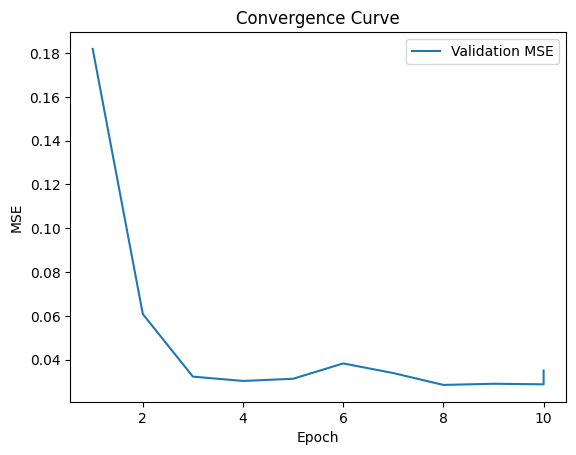

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2400 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/300 [00:00<?, ? examples/s]

In [1]:
# A State Space Model Approach to Cross-Lingual Sentiment Analysis of Filipino Texts 


import os
import pandas as pd
import pprint

from pathlib import Path
from transformers import pipeline

from src.config import *
from src.metrics import evaluate_pipe
from src import (
    context,
    helper,
    sentiment, 
    utility, 
)

os.environ["HF_DATASETS_DISABLE_CACHING"] = "1"
os.environ["TOKENIZERS_PARALLELISM"] = "false"
helper.list_config()

if App.HAS_GPU:
    os.environ["MAMBA_USE_MAMBAPY"] = Mamba.FORCE_CUDA
    os.environ["CUDA_LAUNCH_BLOCKING"] = "1"

if App.ACTION == "TRAIN":
    xlmr_context = context.setup_pipeline(Xlmr, require_translation = False)
    xlmr_trainer = sentiment.train(xlmr_context)

